In [1]:
!pip install GEOparse -q
print("Done")

Done


In [2]:
import GEOparse
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

gse = GEOparse.get_GEO(geo="GSE280299", destdir="./")
print("Downloaded")

11-Jul-2026 22:14:44 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
11-Jul-2026 22:14:44 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE280nnn/GSE280299/soft/GSE280299_family.soft.gz to ./GSE280299_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE280nnn/GSE280299/soft/GSE280299_family.soft.gz to ./GSE280299_family.soft.gz
100%|██████████| 81.9M/81.9M [00:01<00:00, 53.5MB/s]
11-Jul-2026 22:14:46 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
11-Jul-2026 22:14:46 DEBUG downloader - Moving /tmp/tmphlml5_qw to /content/GSE280299_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmphlml5_qw to /content/GSE280299_family.soft.gz
11-Jul-2026 22:14:46 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE280nnn/GSE280299/soft/GSE280299_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/G

Downloaded


In [3]:
import subprocess
subprocess.run(['wget', '-q', '--show-progress',
    'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE280nnn/GSE280299/suppl/GSE280299_Processed_File.txt.gz',
    '-O', 'GSE280299_processed.txt.gz'])

df_full = pd.read_csv('GSE280299_processed.txt.gz', sep='\t', index_col=0)
beta_cols = [col for col in df_full.columns if 'Detection' not in col]
df_beta = df_full[beta_cols]
print(f"Shape: {df_beta.shape}")

Shape: (865918, 56)


In [4]:
exact_ages = {}
for gsm_id, gsm in gse.gsms.items():
    chars = gsm.metadata.get('characteristics_ch1', [])
    for char in chars:
        if char.startswith('age:'):
            age = int(char.split('age: ')[1].strip())
            title = gsm.metadata.get('title', [None])[0]
            exact_ages[title] = age
            break

print(f"Extracted {len(exact_ages)} exact ages")
print(f"Age range: {min(exact_ages.values())} - {max(exact_ages.values())} years")

Extracted 56 exact ages
Age range: 18 - 70 years


In [5]:
forspec_cpgs = {
    'cg23335134': -27.674,
    'cg14961598':  68.752,
    'cg03830712':  15.363,
    'cg26467528': -39.898,
    'cg14728380': 219.148,
    'cg00534655': -15.112,
    'cg03347590': -38.965,
}
intercept = -157.291

df_forspec = df_beta.loc[list(forspec_cpgs.keys())]

predicted_ages = {}
for sample in df_forspec.columns:
    pred = intercept
    for cpg, coef in forspec_cpgs.items():
        pred += coef * df_forspec.loc[cpg, sample]
    predicted_ages[sample] = pred

print("Predictions complete")

Predictions complete


In [6]:
results = pd.DataFrame({
    'chronological_age': exact_ages,
    'predicted_age': predicted_ages
}).dropna()

mae = np.mean(np.abs(results['chronological_age'] - results['predicted_age']))
rmse = np.sqrt(np.mean((results['chronological_age'] - results['predicted_age'])**2))
r, p = stats.pearsonr(results['chronological_age'], results['predicted_age'])

print(f"ForSpEC on Korean cohort (N={len(results)}):")
print(f"MAE  = {mae:.2f} years")
print(f"RMSE = {rmse:.2f} years")
print(f"Pearson R = {r:.3f}, p = {p:.4f}")
print(f"\nFor comparison (Pisarek-Pacek et al. 2026):")
print(f"MAE on American GSE185445 (N=376) = 4.33 years")
print(f"MAE on American GSE185920 (N=1419) = 5.00 years")

ForSpEC on Korean cohort (N=56):
MAE  = 23.81 years
RMSE = 34.16 years
Pearson R = 0.313, p = 0.0189

For comparison (Pisarek-Pacek et al. 2026):
MAE on American GSE185445 (N=376) = 4.33 years
MAE on American GSE185920 (N=1419) = 5.00 years


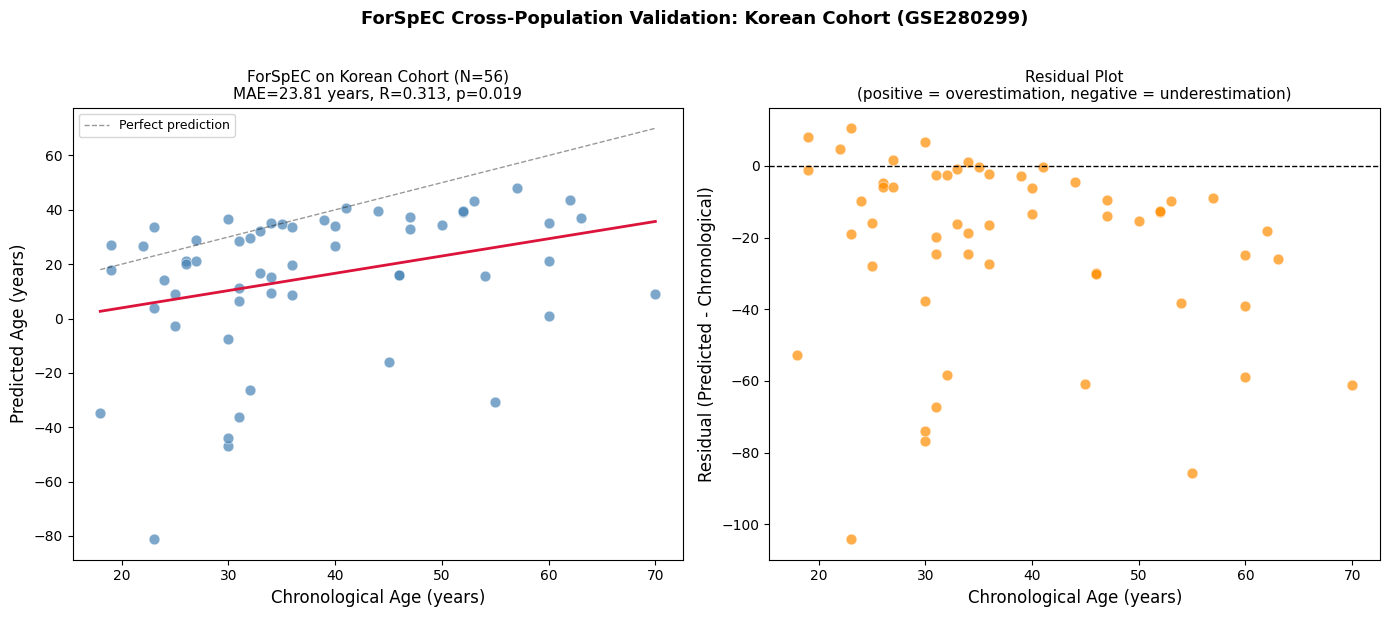

Saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.scatter(results['chronological_age'], results['predicted_age'],
            alpha=0.7, s=60, color='steelblue', edgecolors='white', linewidth=0.5)
m, b = np.polyfit(results['chronological_age'], results['predicted_age'], 1)
x_line = np.linspace(18, 70, 100)
ax1.plot(x_line, m*x_line + b, color='crimson', linewidth=2)
ax1.plot([18, 70], [18, 70], 'k--', linewidth=1, alpha=0.4, label='Perfect prediction')
ax1.set_xlabel('Chronological Age (years)', fontsize=12)
ax1.set_ylabel('Predicted Age (years)', fontsize=12)
ax1.set_title(f'ForSpEC on Korean Cohort (N=56)\nMAE={mae:.2f} years, R={r:.3f}, p={p:.3f}', fontsize=11)
ax1.legend(fontsize=9)

ax2 = axes[1]
residuals = results['predicted_age'] - results['chronological_age']
ax2.scatter(results['chronological_age'], residuals,
            alpha=0.7, s=60, color='darkorange', edgecolors='white', linewidth=0.5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Chronological Age (years)', fontsize=12)
ax2.set_ylabel('Residual (Predicted - Chronological)', fontsize=12)
ax2.set_title('Residual Plot\n(positive = overestimation, negative = underestimation)', fontsize=11)

plt.suptitle('ForSpEC Cross-Population Validation: Korean Cohort (GSE280299)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('forspec_korean_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")